# 03. Embeddings and Feature Extraction

**Topics covered:** Sentence Embeddings · Feature Extraction · Similarity

This notebook builds on the previous [Hugging Face notebooks](https://github.com/S33mi/modern-ai-llm-journey/tree/main/02_huggingface_basics) and shows how to turn text into dense vectors that capture meaning.

We will:
1. Extract **token-level** and **sentence-level** embeddings
2. Use the **feature-extraction** pipeline
3. Load dedicated **sentence-transformer** style models
4. Compute **cosine similarity** and build a tiny semantic search demo
5. Visualise embeddings in 2-D

## 1. Setup & Imports

```bash
pip install transformers torch scikit-learn matplotlib
```

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModel,
    pipeline,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2. What Are Embeddings?

An **embedding** is a dense vector representation of text such that *semantically similar* pieces of text lie close together in vector space.

| Level | Shape | Typical use |
|-------|-------|-------------|
| Token embeddings | `(seq_len, hidden_size)` | Attention visualisation, probing |
| Sentence / document embeddings | `(hidden_size,)` | Search, clustering, classification |

Modern approaches usually mean-pool (or use a special `[CLS]` / `<s>` token) the last hidden states to obtain a single vector per sentence.

## 3. Feature-Extraction Pipeline

The quickest way to get raw hidden states.

In [ ]:
feature_extractor = pipeline(
    "feature-extraction",
    model="sentence-transformers/all-MiniLM-L6-v2",
    device=0 if device == "cuda" else -1,
)

text = "Hugging Face makes transformers easy to use."
features = feature_extractor(text)
# features is a list of lists: [batch][seq_len][hidden_size]
arr = np.array(features)
print("Raw feature shape:", arr.shape)  # (1, seq_len, hidden_size)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Raw feature shape: (1, 10, 384)


## 4. Manual Embedding Extraction (Mean Pooling)

For production code we usually load the model ourselves and apply a clean pooling strategy.

In [ ]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

print("Hidden size:", model.config.hidden_size)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Hidden size: 384


In [ ]:
def mean_pooling(model_output, attention_mask):
    """
    Mean-pool token embeddings, ignoring padding tokens.
    model_output.last_hidden_state: (batch, seq, hidden)
    attention_mask:                (batch, seq)
    """
    token_embeddings = model_output.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    summed = torch.sum(token_embeddings * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def embed_texts(texts, normalize=True):
    """Return sentence embeddings for a list of strings."""
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoded)

    embeddings = mean_pooling(outputs, encoded["attention_mask"])

    if normalize:
        embeddings = F.normalize(embeddings, p=2, dim=1)

    return embeddings.cpu().numpy()

In [ ]:
sentences = [
    "A dog is playing in the park.",
    "The canine is having fun outdoors.",
    "A cat sits on the windowsill.",
    "Quantum physics describes the very small.",
    "I love machine learning and neural networks.",
    "Deep learning is a subset of AI.",
]

embeddings = embed_texts(sentences)
print("Embeddings shape:", embeddings.shape)  # (num_sentences, hidden_size)
print("First vector (first 8 dims):", embeddings[0, :8].round(4))

Embeddings shape: (6, 384)
First vector (first 8 dims): [ 0.0557 -0.0735  0.0638 -0.0131  0.0294  0.0002  0.0828  0.019 ]


## 5. Cosine Similarity

$$
\text{cosine}(a, b) = \frac{a \cdot b}{\|a\| \, \|b\|}
$$

When vectors are already L2-normalised this reduces to a simple dot product.

In [ ]:
sim_matrix = cosine_similarity(embeddings)

print("Cosine similarity matrix:\n")
np.set_printoptions(precision=3, suppress=True)
print(sim_matrix)

# Pretty print pairs
print("\nMost similar pairs:")
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        if sim_matrix[i, j] > 0.5:
            print(f"  [{sim_matrix[i, j]:.3f}]  {sentences[i][:40]}  ↔  {sentences[j][:40]}")

Cosine similarity matrix:

[[ 1.     0.657  0.191 -0.042  0.039  0.043]
 [ 0.657  1.     0.19   0.004  0.032 -0.008]
 [ 0.191  0.19   1.     0.074 -0.022 -0.042]
 [-0.042  0.004  0.074  1.     0.07   0.16 ]
 [ 0.039  0.032 -0.022  0.07   1.     0.578]
 [ 0.043 -0.008 -0.042  0.16   0.578  1.   ]]

Most similar pairs:
  [0.657]  A dog is playing in the park.  ↔  The canine is having fun outdoors.
  [0.578]  I love machine learning and neural netwo  ↔  Deep learning is a subset of AI.


## 6. Tiny Semantic Search

Given a query, rank a corpus by cosine similarity.

In [ ]:
corpus = [
    "How do I train a neural network?",
    "The weather is sunny today.",
    "Best practices for fine-tuning transformers.",
    "Recipes for chocolate cake.",
    "What is gradient descent?",
    "Introduction to convolutional neural networks.",
    "How to bake sourdough bread.",
    "Understanding attention mechanisms in LLMs.",
]

corpus_emb = embed_texts(corpus)

def search(query, top_k=3):
    q_emb = embed_texts([query])
    scores = cosine_similarity(q_emb, corpus_emb)[0]
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    print(f"Query: {query}\n")
    for idx, score in ranked[:top_k]:
        print(f"  {score:.3f}  {corpus[idx]}")


search("How does backpropagation work?")
print()
search("I want to bake something sweet")

Query: How does backpropagation work?

  0.478  What is gradient descent?
  0.412  How do I train a neural network?
  0.378  Introduction to convolutional neural networks.

Query: I want to bake something sweet

  0.542  Recipes for chocolate cake.
  0.517  How to bake sourdough bread.
  0.116  What is gradient descent?


## 7. Visualising Embeddings with PCA

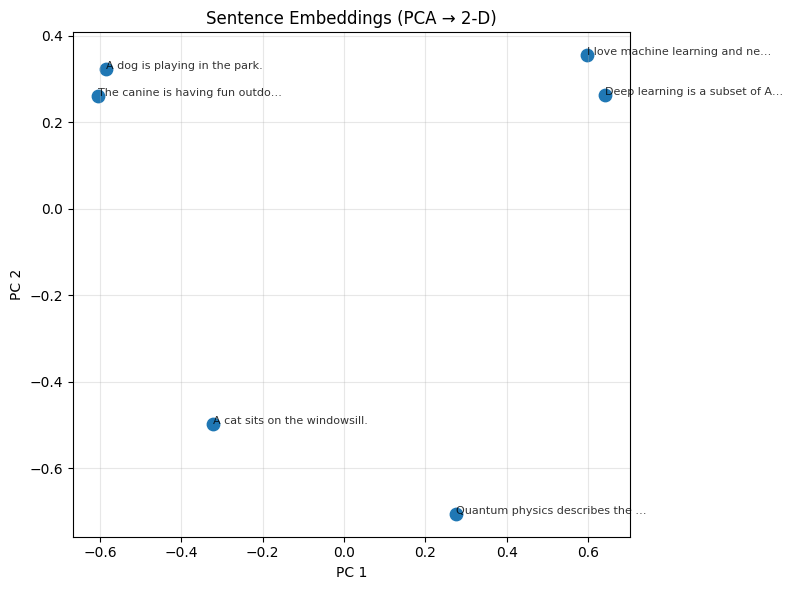

Explained variance: 63.4%


In [ ]:
# Project to 2-D for visualisation
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], s=80)

for i, sent in enumerate(sentences):
    label = sent[:30] + ("…" if len(sent) > 30 else "")
    plt.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.8)

plt.title("Sentence Embeddings (PCA → 2-D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

## 8. CLS / Pooler Output vs Mean Pooling

Some models (especially BERT-style) expose a dedicated `pooler_output` derived from the `[CLS]` token. For sentence-transformers models, **mean pooling** of the last hidden state is usually preferred and is what we used above.

Quick comparison:

In [ ]:
encoded = tokenizer(sentences[:2], padding=True, truncation=True, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**encoded)

if hasattr(out, "pooler_output") and out.pooler_output is not None:
    cls_emb = out.pooler_output
    print("pooler_output shape:", cls_emb.shape)
else:
    # Fall back to first token ([CLS] / <s>)
    cls_emb = out.last_hidden_state[:, 0]
    print("CLS token shape    :", cls_emb.shape)

mean_emb = mean_pooling(out, encoded["attention_mask"])
print("mean-pooled shape  :", mean_emb.shape)

# Cosine between the two strategies for the first sentence
cos = F.cosine_similarity(cls_emb[0], mean_emb[0], dim=0)
print(f"Cosine(CLS, mean)  : {cos.item():.4f}")

pooler_output shape: torch.Size([2, 384])
mean-pooled shape  : torch.Size([2, 384])
Cosine(CLS, mean)  : 0.0606


## 9. Using Embeddings for a Downstream Classifier (Sketch)

Once you have fixed-size vectors you can train any classical model on top of them.

In [ ]:
# Illustrative: two classes
pos = [
    "I really enjoyed this movie.",
    "Fantastic acting and great story.",
    "One of the best films I have seen.",
]
neg = [
    "The plot was boring and predictable.",
    "I wasted two hours of my life.",
    "Terrible acting and weak script.",
]

X = embed_texts(pos + neg)
y = np.array([1, 1, 1, 0, 0, 0])

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X, y)

test = ["What an amazing performance!", "I fell asleep halfway through."]
test_emb = embed_texts(test)
preds = clf.predict(test_emb)
probs = clf.predict_proba(test_emb)[:, 1]

for t, p, pr in zip(test, preds, probs):
    label = "positive" if p == 1 else "negative"
    print(f"{pr:.2f}  {label:8s}  {t}")

0.53  positive  What an amazing performance!
0.45  negative  I fell asleep halfway through.


## 10. Summary

| Concept | Description |
|---------|-------------|
| **Token embeddings** | Per-token hidden states from a Transformer |
| **Sentence embeddings** | Fixed-size vector obtained by pooling token states |
| **Mean pooling** | Average of token vectors weighted by attention mask |
| **Cosine similarity** | Standard metric for comparing normalised embeddings |
| **Semantic search** | Rank documents by similarity to a query vector |
| **Feature-extraction pipeline** | Quick HF pipeline that returns raw hidden states |

### Recommended models for sentence embeddings

| Model | Dims | Notes |
|-------|------|-------|
| `sentence-transformers/all-MiniLM-L6-v2` | 384 | Fast & strong baseline |
| `sentence-transformers/all-mpnet-base-v2` | 768 | Higher quality |
| `BAAI/bge-small-en-v1.5` | 384 | Excellent retrieval performance |
| `intfloat/e5-small-v2` | 384 | Strong general-purpose embeddings |

### Canonical pattern

```python
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

encoded = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**encoded)
embeddings = mean_pooling(out, encoded["attention_mask"])
embeddings = F.normalize(embeddings, p=2, dim=1)
```

---

**You have now completed the `02_huggingface_basics` [series](https://github.com/S33mi/modern-ai-llm-journey/tree/main/02_huggingface_basics).**

Next folder in the curriculum: **`03_finetuning`**  
→ [`01_full_finetuning.ipynb`](https://github.com/S33mi/modern-ai-llm-journey/tree/main/03_finetuning)

---

**For contribution and insihght:** [**S33mi**](https://github.com/S33mi)

Open to Data Analytics and ML/AL related opportunities